# Libraries

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import dask.array as da
from pathlib import Path
import matplotlib.pyplot as plt

from spectralcrop import PathManager

# Load data

In [3]:
INTERIM_DATA = PathManager().get_abs_path_folder("interim")
FIGURES_FOLDER = PathManager().get_abs_path_folder("figures")
ZARR_PATH = INTERIM_DATA + "masked_reflectance.zarr"
REPORTS_DIR = INTERIM_DATA + "reports"

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

In [19]:
ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
mask_nodata = ds["mask_nodata"].astype(np.uint8)
written_bands = ds["written_bands"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")

<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_21824\258817918.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})


## Mover máscara no data hacia zarr principal (ahora está en interim/reports)

In [ ]:
# Rutas (usando tu PathManager)
INTERIM_DIR = Path(PathManager().get_abs_path_folder("interim"))
ZARR_MAIN  = INTERIM_DIR / "masked_reflectance.zarr"
ZARR_MASK  = INTERIM_DIR / "reports" / "mask_nodata.zarr"

# Abrimos el Zarr principal con chunks compatibles
ds_main = xr.open_zarr(ZARR_MAIN, chunks={"band": 64, "y": 512, "x": 512})

# Abrimos el Zarr de máscara (puede traer un solo DataArray)
ds_mask = xr.open_zarr(ZARR_MASK)

print("Variables en mask_nodata.zarr:", list(ds_mask.data_vars))
print("Dims main:", ds_main.dims)

Variables en mask_nodata.zarr: ['mask_nodata']
Dims main: FrozenMappingWarningOnValuesAccess({'band': 379, 'y': 3660, 'x': 3438})


C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_8848\1178984255.py:7: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds_main = xr.open_zarr(ZARR_MAIN, chunks={"band": 64, "y": 512, "x": 512})
C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_8848\1178984255.py:7: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds_main = xr.open_zarr(ZARR_MAIN, chunks={"band": 64, "y": 512, "x": 512})


In [ ]:

ds_main

<xarray.Dataset> Size: 19GB
Dimensions:        (band: 379, y: 3660, x: 3438)
Coordinates:
  * band           (band) int32 2kB 0 1 2 3 4 5 6 ... 373 374 375 376 377 378
Dimensions without coordinates: y, x
Data variables:
    fwhm           (band) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    veg_mask       (y, x) uint8 13MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    NDVI           (y, x) float32 50MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    written_bands  (band) uint8 379B dask.array<chunksize=(64,), meta=np.ndarray>
    wavelength     (band) float32 2kB dask.array<chunksize=(64,), meta=np.ndarray>
    reflectance    (band, y, x) float32 19GB dask.array<chunksize=(64, 512, 512), meta=np.ndarray>
Attributes:
    description:            Reflectance cube (raw)
    units:                  unitless
    scale_applied:          10000.0
    clip_applied:           [0,1.2]
    nodata:                 NaN
    exclude_water_windows:  True
    water_windows_nm:       [[1340.0, 1440.0], [1800.0, 1950.0]]

In [8]:
ds_mask

<xarray.Dataset> Size: 13MB
Dimensions:      (y: 3660, x: 3438)
Dimensions without coordinates: y, x
Data variables:
    mask_nodata  (y, x) uint8 13MB dask.array<chunksize=(512, 512), meta=np.ndarray>

In [9]:

mask_var_name = next(iter(ds_mask.data_vars))
mask = ds_mask[mask_var_name]
print(mask_var_name)
mask

mask_nodata


<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x

In [14]:
# Asegurar que la máscara tenga dims (y, x) en ese orden
if set(mask.dims) != {"y", "x"}:
    # Si vienen otros dims (p.ej., ("rows","cols") o el orden inverso)
    # intenta transponer a (y,x)
    try:
        mask = mask.transpose("y", "x")
    except Exception as e:
        raise RuntimeError(f"No pude transponer la máscara a (y,x). Dims actuales: {mask.dims}") from e

mask

<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x

In [13]:



# Verificar tamaño y coord alignment con el Zarr principal
for dim in ("y", "x"):
    if dim not in ds_main.dims:
        raise RuntimeError(f"El Zarr principal no tiene dimensión '{dim}'. Dims: {ds_main.dims}")
    if ds_main.sizes[dim] != mask.sizes[dim]:
        raise RuntimeError(
            f"Desajuste espacial en '{dim}': main={ds_main.sizes[dim]} vs mask={mask.sizes[dim]}"
        )


In [15]:

# Revisar valores únicos (rápido con Dask; trae solo el histograma)
uniq = np.unique(mask.data.compute()) if isinstance(mask.data, da.Array) else np.unique(mask.values)
print("Valores únicos en la máscara:", uniq)


Valores únicos en la máscara: [0 1]


In [17]:
mask.values

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(3660, 3438), dtype=uint8)

In [18]:
# --- Escribir 'mask_nodata' en masked_reflectance.zarr ---
# Aseguramos chunking y tipo 'uint8' (compacto y claro)
mask_to_write = mask.astype("uint8").chunk({"y": 512, "x": 512}).rename("mask_nodata")
mask_to_write.attrs.update({
    "long_name": "NoData mask (0=valid, 1=NoData)",
    "source": str(ZARR_MASK),
})

# Escribimos agregando la variable al grupo existente
xr.Dataset({"mask_nodata": mask_to_write}).to_zarr(ZARR_MAIN, mode="a")
print("mask_nodata escrita en el Zarr principal:", ZARR_MAIN)

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


mask_nodata escrita en el Zarr principal: c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\interim\masked_reflectance.zarr


In [ ]:
# Reconsolidar metadatos Zarr

import zarr

store = zarr.DirectoryStore(str(ZARR_MAIN))
zarr.consolidate_metadata(store)
print("Metadatos Zarr reconsolidados.")

AttributeError: module 'zarr' has no attribute 'DirectoryStore'

In [20]:
# Reabrir y verificar que la variable esté disponible y aliñada
ds_check = xr.open_zarr(ZARR_MAIN, chunks={"band": 64, "y": 512, "x": 512})
assert "mask_nodata" in ds_check.data_vars, "mask_nodata no se encontró en el Zarr principal."
print(ds_check["mask_nodata"])

<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  NoData mask (0=valid, 1=NoData)
    source:     c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\int...


C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_8848\606238354.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds_check = xr.open_zarr(ZARR_MAIN, chunks={"band": 64, "y": 512, "x": 512})


# Cálculo de índices de vegetación adicionales

In [14]:
mask_nodata

<xarray.DataArray 'mask_nodata' (y: 3660, x: 3438)> Size: 13MB
dask.array<open_dataset-mask_nodata, shape=(3660, 3438), dtype=uint8, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    long_name:  NoData mask (0=valid, 1=NoData)
    source:     c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\int...

In [17]:
mask_nodata.values

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(3660, 3438), dtype=uint8)

In [15]:
veg_mask

<xarray.DataArray 'veg_mask' (y: 3660, x: 3438)> Size: 13MB
dask.array<astype, shape=(3660, 3438), dtype=bool, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    0:                  no-veg
    1:                  veg
    dimension_names:    ['y', 'x']
    _ARRAY_DIMENSIONS:  ['y', 'x']

In [16]:
veg_mask.values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(3660, 3438))

In [21]:
# --- PARCHE DE MÁSCARA (convenciones explícitas) ---
# veg_mask: bool -> True = vegetación, False = no-veg
# mask_nodata: uint8 -> 0 = válido, 1 = NoData

def valid_veg_mask(veg_da: xr.DataArray, nodata_da: xr.DataArray):
    """
    Retorna True únicamente en píxeles de vegetación (veg=True) con datos válidos (mask_nodata==0).
    """
    return (veg_da) & (nodata_da == 0)


def safe_div(a: xr.DataArray, b: xr.DataArray):
    return a / xr.where(np.abs(b) < 1e-6, np.nan, b)


In [43]:
def nearest_band(center_nm: float, wl: np.ndarray):
    i = int(np.argmin(np.abs(wl - float(center_nm))))
    return i, float(wl[i])

def nearest_in_range(wl_min: float, wl_max: float, wl: np.ndarray):
    center = (wl_min + wl_max) / 2.0
    mask = (wl >= wl_min) & (wl <= wl_max)
    if not mask.any():
        return nearest_band(center, wl)
    idxs = np.where(mask)[0]
    i_local = int(np.argmin(np.abs(wl[idxs] - center)))
    j = int(idxs[i_local])
    return j, float(wl[j])

# Longitudes objetivo (ventanas canónicas flexibles)
# Green: 540–560 nm | Red-edge: 705–740 nm | NIR: 780–840 nm
# PRI: 531±5, 570±5 | PSRI: 500±5, 680±5, 750±5
band_green, wl_green = nearest_in_range(540, 560, wavelengths)
band_re,    wl_re    = nearest_in_range(705, 740, wavelengths)
band_nir,   wl_nir   = nearest_in_range(780, 840, wavelengths)

band_531, wl_531 = nearest_in_range(526, 536, wavelengths)
band_570, wl_570 = nearest_in_range(565, 575, wavelengths)

band_500, wl_500 = nearest_in_range(495, 505, wavelengths)
band_680, wl_680 = nearest_in_range(675, 685, wavelengths)
band_750, wl_750 = nearest_in_range(745, 755, wavelengths)

# (Opcional) Red para referencia (no lo usamos en índices nuevos pero útil para QA)
band_red, wl_red = nearest_in_range(660, 680, wavelengths)

bands_used_map = {
    "GREEN": (band_green, wl_green),
    "RED_EDGE": (band_re, wl_re),
    "NIR": (band_nir, wl_nir),
    "PRI_531": (band_531, wl_531),
    "PRI_570": (band_570, wl_570),
    "PSRI_500": (band_500, wl_500),
    "PSRI_680": (band_680, wl_680),
    "PSRI_750": (band_750, wl_750),
    "REF_RED": (band_red, wl_red),
}
pd.DataFrame(
    [(k, i, wl) for k,(i,wl) in bands_used_map.items()],
    columns=["key","band_index","wavelength_nm"]
)

,key,band_index,wavelength_nm
0,GREEN,48,550.580688
1,RED_EDGE,107,722.109497
2,NIR,137,809.327576
3,PRI_531,41,530.229797
4,PRI_570,55,570.931580
5,PSRI_500,31,501.157135
6,PSRI_680,93,681.407776
7,PSRI_750,117,751.182190
8,REF_RED,89,669.778687


In [44]:
# Extraer reflectancias por banda
R = refl_byx  # (band,y,x)
R_green = R.isel(band=band_green)
R_re    = R.isel(band=band_re)
R_nir   = R.isel(band=band_nir)

R_531 = R.isel(band=band_531)
R_570 = R.isel(band=band_570)

R_500 = R.isel(band=band_500)
R_680 = R.isel(band=band_680)
R_750 = R.isel(band=band_750)

# Índices perezosos
NDRE    = safe_div(R_nir - R_re,  R_nir + R_re).rename("NDRE").astype("float32")
CIgreen = (safe_div(R_nir, R_green) - 1.0).rename("CIgreen").astype("float32")
PRI     = safe_div(R_531 - R_570, R_531 + R_570).rename("PRI").astype("float32")
PSRI    = safe_div(R_680 - R_500, R_750).rename("PSRI").astype("float32")

# Aplicar máscara (veg válida) y mantener pereza
m_valid = valid_veg_mask(veg_mask, mask_nodata)
NDRE_m    = NDRE.where(m_valid)
CIgreen_m = CIgreen.where(m_valid)
PRI_m     = PRI.where(m_valid)
PSRI_m    = PSRI.where(m_valid)

In [45]:
# Atributos informativos
meta_common = {
    "note": "Computed from reflectance using nearest available bands to canonical wavelengths.",
    "mask_applied": "veg_mask & (mask_nodata==0)",
    "units": "unitless",
}
NDRE_m.attrs.update({**meta_common, "formula": "(NIR - RE) / (NIR + RE)",
                     "bands_nm": {"NIR": wl_nir, "RE": wl_re}})
CIgreen_m.attrs.update({**meta_common, "formula": "NIR / GREEN - 1",
                        "bands_nm": {"NIR": wl_nir, "GREEN": wl_green}})
PRI_m.attrs.update({**meta_common, "formula": "(R531 - R570) / (R531 + R570)",
                    "bands_nm": {"531": wl_531, "570": wl_570}})
PSRI_m.attrs.update({**meta_common, "formula": "(R680 - R500) / R750",
                     "bands_nm": {"680": wl_680, "500": wl_500, "750": wl_750}})


In [46]:
NDRE_m

<xarray.DataArray 'NDRE' (y: 3660, x: 3438)> Size: 50MB
dask.array<where, shape=(3660, 3438), dtype=float32, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    note:          Computed from reflectance using nearest available bands to...
    mask_applied:  veg_mask & (mask_nodata==0)
    units:         unitless
    formula:       (NIR - RE) / (NIR + RE)
    bands_nm:      {'NIR': 809.3275756835938, 'RE': 722.1094970703125}

In [47]:
NDRE_m.values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(3660, 3438), dtype=float32)

In [48]:
NDRE_m.values.sum().sum()

np.float32(nan)

In [49]:
CIgreen_m

<xarray.DataArray 'CIgreen' (y: 3660, x: 3438)> Size: 50MB
dask.array<where, shape=(3660, 3438), dtype=float32, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    note:          Computed from reflectance using nearest available bands to...
    mask_applied:  veg_mask & (mask_nodata==0)
    units:         unitless
    formula:       NIR / GREEN - 1
    bands_nm:      {'NIR': 809.3275756835938, 'GREEN': 550.5806884765625}

In [50]:
PRI_m

<xarray.DataArray 'PRI' (y: 3660, x: 3438)> Size: 50MB
dask.array<where, shape=(3660, 3438), dtype=float32, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    note:          Computed from reflectance using nearest available bands to...
    mask_applied:  veg_mask & (mask_nodata==0)
    units:         unitless
    formula:       (R531 - R570) / (R531 + R570)
    bands_nm:      {'531': 530.2297973632812, '570': 570.9315795898438}

In [51]:
PSRI_m

<xarray.DataArray 'PSRI' (y: 3660, x: 3438)> Size: 50MB
dask.array<where, shape=(3660, 3438), dtype=float32, chunksize=(512, 512), chunktype=numpy.ndarray>
Coordinates:
    band     int32 4B 117
Dimensions without coordinates: y, x
Attributes:
    note:          Computed from reflectance using nearest available bands to...
    mask_applied:  veg_mask & (mask_nodata==0)
    units:         unitless
    formula:       (R680 - R500) / R750
    bands_nm:      {'680': 681.4077758789062, '500': 501.1571350097656, '750'...

## Validación de cálculo de índices

In [52]:
def quick_valid_fraction(da):
    # proporción de valores finitos vs. total (ignora chunks hasta el compute final)
    finite = xr.ufuncs.isfinite(da)
    num = finite.sum().compute()
    den = da.sizes["y"] * da.sizes["x"]
    return float(num) / float(den)

for name, arr in [("NDRE", NDRE_m), ("CIgreen", CIgreen_m), ("PRI", PRI_m), ("PSRI", PSRI_m)]:
    frac = quick_valid_fraction(arr)
    print(f"{name}: frac_finite={frac:.4f}")

NDRE: frac_finite=0.4812
CIgreen: frac_finite=0.3963
PRI: frac_finite=0.4380
PSRI: frac_finite=0.4775


In [53]:
m_valid = (veg_mask) & (mask_nodata == 0)
print("¿m_valid tiene 'True'?:", bool(m_valid.any().compute()))
print("Cobertura m_valid:", int(m_valid.sum().compute()))

¿m_valid tiene 'True'?: True
Cobertura m_valid: 6055113


In [54]:
def quick_stats(da):
    # calcula p5/mediana/p95 sólo en finitos
    vals = da.where(xr.ufuncs.isfinite(da))
    q = vals.quantile([0.05, 0.5, 0.95])
    return q.compute()

for name, arr in [("NDRE", NDRE_m), ("CIgreen", CIgreen_m), ("PRI", PRI_m), ("PSRI", PSRI_m)]:
    q = quick_stats(arr)
    print(f"\n{name} percentiles:")
    print(q.to_pandas())


NDRE percentiles:
quantile
0.05    0.248641
0.50    0.355699
0.95    0.465401
Name: NDRE, dtype: float64

CIgreen percentiles:
quantile
0.05     3.547231
0.50     6.204852
0.95    10.673470
Name: CIgreen, dtype: float64

PRI percentiles:
quantile
0.05   -0.086860
0.50   -0.011561
0.95    0.015251
Name: PRI, dtype: float64

PSRI percentiles:
quantile
0.05   -0.001027
0.50    0.004645
0.95    0.090452
Name: PSRI, dtype: float64


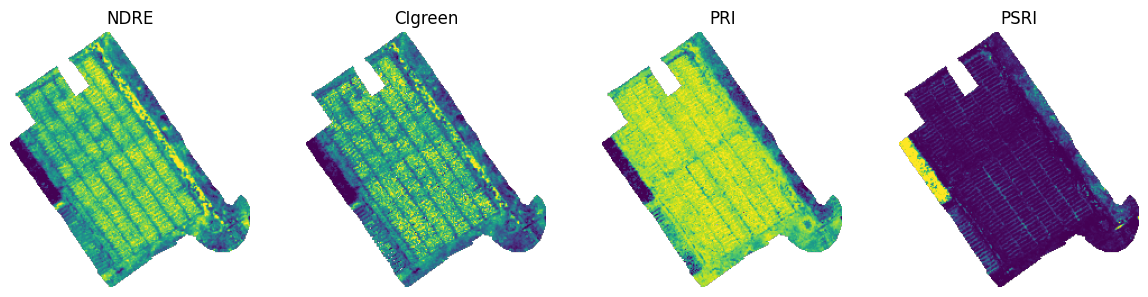

In [55]:
def stretch(img, p=(2,98)):
    lo, hi = np.nanpercentile(img, p)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

coarsen_factor = 16  # más agresivo -> más barato
indices_low = xr.Dataset({
    "NDRE":   NDRE_m,
    "CIgreen": CIgreen_m,
    "PRI":     PRI_m,
    "PSRI":    PSRI_m,
}).coarsen(y=coarsen_factor, x=coarsen_factor, boundary="trim").mean().compute()

fig, ax = plt.subplots(1,4, figsize=(12,3))
for i, name in enumerate(["NDRE","CIgreen","PRI","PSRI"]):
    ax[i].imshow(stretch(indices_low[name].values), cmap="viridis")
    ax[i].set_title(name); ax[i].axis("off")
plt.tight_layout(); plt.show()

## Guardar índices en Zarr

In [56]:
# --- 1) Función utilitaria: dejar sólo coords espaciales (y,x) ---
def keep_only_yx_coords(da: xr.DataArray) -> xr.DataArray:
    extra = [c for c in da.coords if c not in ("y", "x")]
    # reset_coords(names=[...], drop=True) elimina coords extra (incluida 'band' escalar)
    if extra:
        da = da.reset_coords(extra, drop=True)
    return da

# --- 2) Aplicar a cada índice antes de escribir ---
NDRE_w    = keep_only_yx_coords(NDRE_m).chunk({"y": 512, "x": 512}).astype("float32")
CIgreen_w = keep_only_yx_coords(CIgreen_m).chunk({"y": 512, "x": 512}).astype("float32")
PRI_w     = keep_only_yx_coords(PRI_m).chunk({"y": 512, "x": 512}).astype("float32")
PSRI_w    = keep_only_yx_coords(PSRI_m).chunk({"y": 512, "x": 512}).astype("float32")

# (Opcional) inspección rápida por si quedara alguna coord colada
for name, da in {"NDRE": NDRE_w, "CIgreen": CIgreen_w, "PRI": PRI_w, "PSRI": PSRI_w}.items():
    print(name, "coords:", list(da.coords))  # debería listar solo ['y','x'] o incluso ninguna coord explícita



NDRE coords: []
CIgreen coords: []
PRI coords: []
PSRI coords: []


In [57]:
NDRE_w

<xarray.DataArray 'NDRE' (y: 3660, x: 3438)> Size: 50MB
dask.array<where, shape=(3660, 3438), dtype=float32, chunksize=(512, 512), chunktype=numpy.ndarray>
Dimensions without coordinates: y, x
Attributes:
    note:          Computed from reflectance using nearest available bands to...
    mask_applied:  veg_mask & (mask_nodata==0)
    units:         unitless
    formula:       (NIR - RE) / (NIR + RE)
    bands_nm:      {'NIR': 809.3275756835938, 'RE': 722.1094970703125}

In [58]:

# --- 3) Escribir en la raíz del mismo Zarr ---
to_write = xr.Dataset({
    "NDRE": NDRE_w,
    "CIgreen": CIgreen_w,
    "PRI": PRI_w,
    "PSRI": PSRI_w,
})

# Usa exactamente el mismo ZARR_PATH que abriste:
to_write.to_zarr(ZARR_PATH, mode="a")
print("Índices escritos en:", ZARR_PATH)

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Índices escritos en: c:\Users\JMONTOYA\Documents\personal_projects\thesis\data\interim\masked_reflectance.zarr


In [59]:
ds_check = xr.open_zarr(ZARR_PATH, consolidated=False, chunks={"y": 512, "x": 512})
print("Dataset attrs:", dict(ds_check.attrs))  # puede estar vacío si nunca los configuraste a nivel dataset

for var in ["NDRE","CIgreen","PRI","PSRI"]:
    if var in ds_check:
        print(f"{var} attrs:", dict(ds_check[var].attrs))

Dataset attrs: {}
NDRE attrs: {'note': 'Computed from reflectance using nearest available bands to canonical wavelengths.', 'mask_applied': 'veg_mask & (mask_nodata==0)', 'units': 'unitless', 'formula': '(NIR - RE) / (NIR + RE)', 'bands_nm': {'NIR': 809.3275756835938, 'RE': 722.1094970703125}}
CIgreen attrs: {'note': 'Computed from reflectance using nearest available bands to canonical wavelengths.', 'mask_applied': 'veg_mask & (mask_nodata==0)', 'units': 'unitless', 'formula': 'NIR / GREEN - 1', 'bands_nm': {'NIR': 809.3275756835938, 'GREEN': 550.5806884765625}}
PRI attrs: {'note': 'Computed from reflectance using nearest available bands to canonical wavelengths.', 'mask_applied': 'veg_mask & (mask_nodata==0)', 'units': 'unitless', 'formula': '(R531 - R570) / (R531 + R570)', 'bands_nm': {'531': 530.2297973632812, '570': 570.9315795898438}}
PSRI attrs: {'note': 'Computed from reflectance using nearest available bands to canonical wavelengths.', 'mask_applied': 'veg_mask & (mask_nodata=

In [60]:
ds_check

<xarray.Dataset> Size: 19GB
Dimensions:        (y: 3660, x: 3438, band: 379)
Coordinates:
  * band           (band) int32 2kB 0 1 2 3 4 5 6 ... 373 374 375 376 377 378
Dimensions without coordinates: y, x
Data variables:
    CIgreen        (y, x) float32 50MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    mask_nodata    (y, x) uint8 13MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    fwhm           (band) float32 2kB dask.array<chunksize=(379,), meta=np.ndarray>
    reflectance    (band, y, x) float32 19GB dask.array<chunksize=(64, 512, 512), meta=np.ndarray>
    veg_mask       (y, x) uint8 13MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    NDVI           (y, x) float32 50MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    PRI            (y, x) float32 50MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    wavelength     (band) float32 2kB dask.array<chunksize=(379,), meta=np.ndarray>
    PSRI           (y, x) float32 50MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    written_bands  (band) uint8 379B dask.array<chunksize=(379,), meta=np.ndarray>
    NDRE           (y, x) float32 50MB dask.array<chunksize=(512, 512), meta=np.ndarray>

In [61]:
indices_info = pd.DataFrame([
    ["NDRE",    "NIR,RE", wl_nir, wl_re,    band_nir, band_re,    "(NIR-RE)/(NIR+RE)"],
    ["CIgreen", "NIR,GREEN", wl_nir, wl_green, band_nir, band_green, "NIR/GREEN - 1"],
    ["PRI",     "531,570", wl_531, wl_570,  band_531, band_570,   "(R531-R570)/(R531+R570)"],
    ["PSRI",    "680,500,750", wl_680, wl_500, band_680, band_500, "(R680-R500)/R750 (750nm)"],
], columns=["index","bands_used","wl_1_nm","wl_2_nm","band_1","band_2","formula"])

# Añadimos una fila extra para la tercera banda de PSRI (750 nm)
indices_info_extra = pd.DataFrame([
    ["PSRI_extra", "750", wl_750, np.nan, band_750, np.nan, "Denominator band (750nm)"],
], columns=indices_info.columns)


indices_info

,index,bands_used,wl_1_nm,wl_2_nm,band_1,band_2,formula
0,NDRE,"NIR,RE",809.327576,722.109497,137,107,(NIR-RE)/(NIR+RE)
1,CIgreen,"NIR,GREEN",809.327576,550.580688,137,48,NIR/GREEN - 1
2,PRI,"531,570",530.229797,570.931580,41,55,(R531-R570)/(R531+R570)
3,PSRI,"680,500,750",681.407776,501.157135,93,31,(R680-R500)/R750 (750nm)


In [62]:
indices_info_extra

,index,bands_used,wl_1_nm,wl_2_nm,band_1,band_2,formula
0,PSRI_extra,750,751.18219,NaN,117,NaN,Denominator band (750nm)


In [63]:
pd.concat([indices_info, indices_info_extra], ignore_index=True)

,index,bands_used,wl_1_nm,wl_2_nm,band_1,band_2,formula
0,NDRE,"NIR,RE",809.327576,722.109497,137,107.0,(NIR-RE)/(NIR+RE)
1,CIgreen,"NIR,GREEN",809.327576,550.580688,137,48.0,NIR/GREEN - 1
2,PRI,"531,570",530.229797,570.931580,41,55.0,(R531-R570)/(R531+R570)
3,PSRI,"680,500,750",681.407776,501.157135,93,31.0,(R680-R500)/R750 (750nm)
4,PSRI_extra,750,751.182190,NaN,117,NaN,Denominator band (750nm)


In [65]:
info_df = pd.concat([indices_info, indices_info_extra], ignore_index=True)
out_csv = INTERIM_DATA + "/indices_bands_used.csv"
info_df.to_csv(out_csv, index=False)
out_csv

'c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\data\\interim\\/indices_bands_used.csv'